# Baseline Model: LightGBM on CMAPSS FD001
Rolling window features, engine-aware train/val split, RMSE + NASA score.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import root_mean_squared_error

In [4]:
df = pd.read_parquet('../data/train_FD001_clean.parquet')

sensor_cols = [c for c in df.columns if c.startswith('sensor_')]

## 1. Rolling window features

In [5]:
WINDOW = 5

def add_rolling(group):
    group = group.copy()
    rolled = (
        group[sensor_cols]
        .rolling(WINDOW, min_periods=WINDOW)
    )
    for col in sensor_cols:
        group[f'{col}_rmean'] = rolled[col].mean()
        group[f'{col}_rstd']  = rolled[col].std()
    return group

df = df.groupby('engine_id', group_keys=False).apply(add_rolling)

# first WINDOW-1 rows per engine have no complete window, drop them
df = df.dropna().reset_index(drop=True)

print(f'{df.shape[0]} rows after dropping incomplete windows')

20231 rows after dropping incomplete windows


/tmp/ipykernel_30773/4210062282.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('engine_id', group_keys=False).apply(add_rolling)


## 2. Train / validation split by engine

In [6]:
# splitting by engine prevents any engine's future cycles leaking into training
engine_ids = sorted(df['engine_id'].unique())
n_val = max(1, int(len(engine_ids) * 0.2))
val_engines = set(engine_ids[-n_val:])

train_df = df[~df['engine_id'].isin(val_engines)]
val_df   = df[ df['engine_id'].isin(val_engines)]

print(f'train engines: {len(engine_ids) - n_val}  ({len(train_df)} rows)')
print(f'val engines:   {n_val}  ({len(val_df)} rows)')

feature_cols = [c for c in df.columns if c not in ('engine_id', 'cycle', 'rul')]

X_train, y_train = train_df[feature_cols], train_df['rul']
X_val,   y_val   = val_df[feature_cols],   val_df['rul']

train engines: 80  (15818 rows)
val engines:   20  (4413 rows)


## 3. Train LightGBM

In [7]:
model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)],
)

print(f'best iteration: {model.best_iteration_}')

[100]	valid_0's l2: 2228.53
best iteration: 115


## 4. Evaluation

In [8]:
def nasa_score(y_true, y_pred):
    d = np.array(y_pred) - np.array(y_true)
    # asymmetric: late predictions (positive d) are penalised harder
    penalties = np.where(d < 0, np.expm1(-d / 13), np.expm1(d / 10))
    return penalties.sum()

preds = model.predict(X_val)

rmse  = root_mean_squared_error(y_val, preds)
score = nasa_score(y_val, preds)

print(f'RMSE:       {rmse:.2f}')
print(f'NASA score: {score:.2f}  (lower is better)')

RMSE:       47.15
NASA score: 38175097.19  (lower is better)


## 5. Predicted vs actual RUL

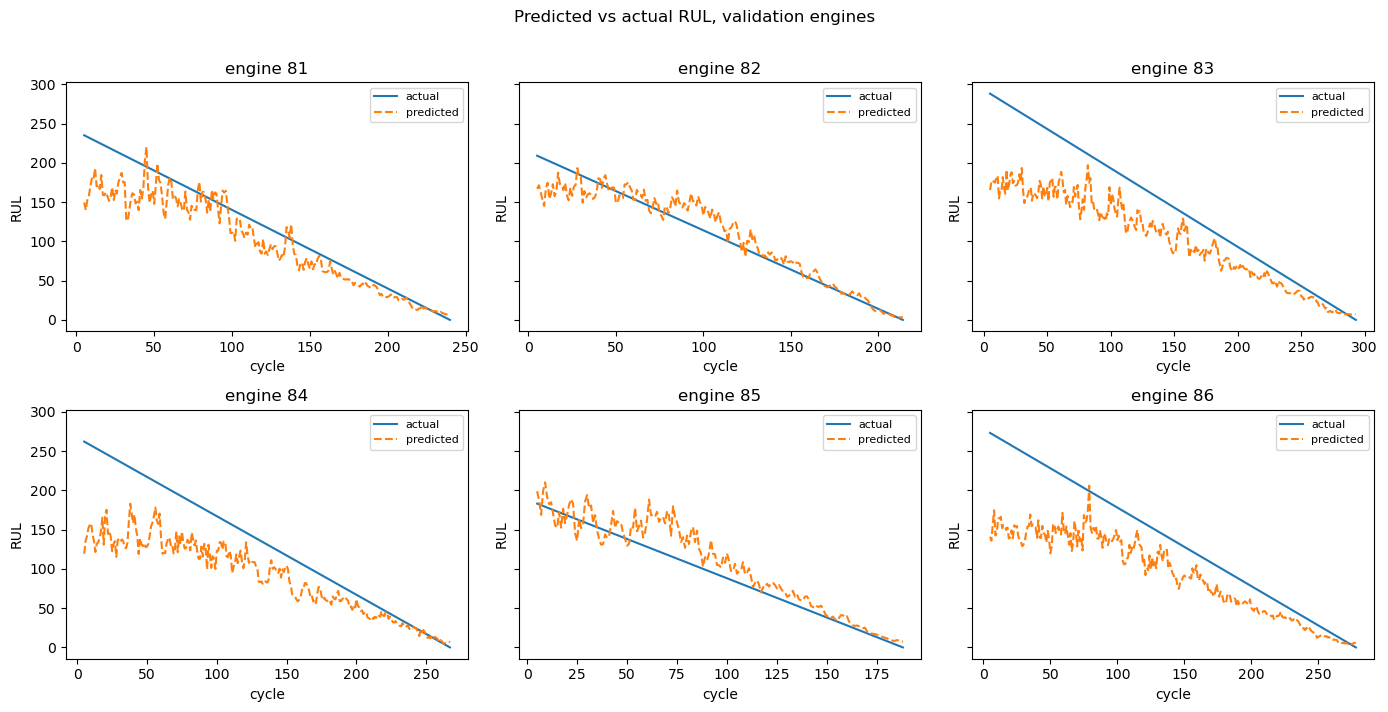

In [9]:
val_plot = val_df[['engine_id', 'cycle', 'rul']].copy()
val_plot['pred_rul'] = preds

sample_engines = sorted(val_plot['engine_id'].unique())[:6]
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=True)

for ax, eid in zip(axes.flat, sample_engines):
    eng = val_plot[val_plot['engine_id'] == eid].sort_values('cycle')
    ax.plot(eng['cycle'], eng['rul'],      label='actual', lw=1.5)
    ax.plot(eng['cycle'], eng['pred_rul'], label='predicted', lw=1.5, linestyle='--')
    ax.set_title(f'engine {eid}')
    ax.set_xlabel('cycle')
    ax.set_ylabel('RUL')
    ax.legend(fontsize=8)

plt.suptitle('Predicted vs actual RUL, validation engines', y=1.01)
plt.tight_layout()
plt.show()

## 6. Feature importances

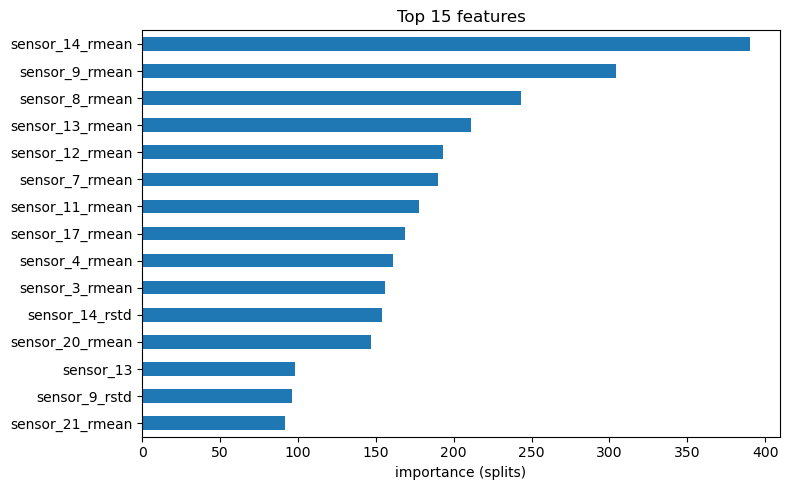

sensor_14_rmean    390
sensor_9_rmean     304
sensor_8_rmean     243
sensor_13_rmean    211
sensor_12_rmean    193
sensor_7_rmean     190
sensor_11_rmean    178
sensor_17_rmean    169
sensor_4_rmean     161
sensor_3_rmean     156
sensor_14_rstd     154
sensor_20_rmean    147
sensor_13           98
sensor_9_rstd       96
sensor_21_rmean     92


In [10]:
importances = (
    pd.Series(model.feature_importances_, index=feature_cols)
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot.barh(ax=ax)
ax.invert_yaxis()
ax.set_xlabel('importance (splits)')
ax.set_title('Top 15 features')
plt.tight_layout()
plt.show()

print(importances.to_string())